<a href="https://colab.research.google.com/github/mario-amaro/IASCA/blob/main/Ejercicio_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EJERCICIO 1: ANÁLISIS DE DATOS DE EXOPLANETAS

### Importación de librerías y datos de análisis



In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

UNIDADES DE LAS COLUMNAS
*   planeta:        Planet Name
*   estrella:       Host Name
*   sy_snum:        Number of Stars
*   sy_pnum:        Number of Planets
*   discoverymethod: Discovery Method
*   disc_year:      Discovery Year
*   disc_facility:  Discovery Facility
*   periodo_orb:    Orbital Period [days]
*   pl_orbsmax:     Orbit Semi-Major Axis [au]
*   pl_rade:        Planet Radius [Earth Radius]
*   pl_radj:        Planet Radius [Jupiter Radius]
*   pl_masse:       Planet Mass [Earth Mass]
*   pl_massj:       Planet Mass [Jupiter Mass]
*   pl_orbeccen:    Eccentricity
*   pl_insol:       Insolation Flux [Earth Flux]
*   pl_eqt:         Equilibrium Temperature [K]
*   st_spectype:    Spectral Type
*   st_teff:        Stellar Effective Temperature [K]
*   st_rad:         Stellar Radius [Solar Radius]
*   st_mass:        Stellar Mass [Solar mass]
*   distancia:        Distance [pc]



In [2]:
planets = pd.read_csv("/content/sample_data/PS_2026.03.06_12.52.14.csv")

In [3]:
####  TRATAMIENTO PREVIO DE COLUMNAS  ####

#cambios de nombre
planets=planets.rename(columns={"pl_name":"planeta","hostname":"estrella","pl_orbper":"periodo_orb","sy_dist;":"distancia"})

#Corrección de un error por el que aparece ; al final de cada fila por la conversión desde el csv
planets['distancia'] = pd.to_numeric(planets['distancia'].astype(str).str.rstrip(';'), errors='coerce')

#Eliminación de algunas columnas
planets=planets.drop(columns={"sy_snum","sy_pnum","disc_facility","pl_eqt","pl_massj","pl_radj"})

#Muestra de la tabla final
planets.head()

,planeta,estrella,discoverymethod,disc_year,periodo_orb,pl_orbsmax,pl_rade,pl_masse,pl_orbeccen,pl_insol,st_spectype,st_teff,st_rad,st_mass,distancia
0,11 Com b,11 Com,Radial Velocity,2007.0,323.21000,1.178,NaN,NaN,0.238,NaN,G8 III,4874.0,13.76,2.09,93.1846
1,11 Com b,11 Com,Radial Velocity,2007.0,326.03000,1.290,NaN,NaN,0.231,NaN,G8 III,4742.0,19.00,2.70,93.1846
2,11 Com b,11 Com,Radial Velocity,2007.0,NaN,1.210,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.60,93.1846
3,11 UMi b,11 UMi,Radial Velocity,2009.0,516.22000,1.540,NaN,NaN,0.080,NaN,K4 III,4340.0,24.08,1.80,125.3210
4,11 UMi b,11 UMi,Radial Velocity,2009.0,516.21997,1.530,NaN,NaN,0.080,NaN,NaN,4213.0,29.79,2.78,125.3210




---





---



### Información sobre los datos

In [ ]:
planets.info()

print("\nNúmero de filas: ",len(planets))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39476 entries, 0 to 39475
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   planeta          39476 non-null  object 
 1   estrella         39476 non-null  object 
 2   discoverymethod  39476 non-null  object 
 3   disc_year        39474 non-null  float64
 4   periodo_orb      36154 non-null  float64
 5   pl_orbsmax       22142 non-null  float64
 6   pl_rade          27175 non-null  float64
 7   pl_masse         4864 non-null   float64
 8   pl_orbeccen      18861 non-null  float64
 9   pl_insol         17195 non-null  float64
 10  st_spectype      2962 non-null   object 
 11  st_teff          35936 non-null  float64
 12  st_rad           36124 non-null  float64
 13  st_mass          33273 non-null  float64
 14  distancia        38623 non-null  float64
dtypes: float64(11), object(4)
memory usage: 4.5+ MB

Número de filas:  39476


    Vemos que tiene 15 columnas de datos, listadas en la tabla, y en total 39476 entradas de datos.

    Los tipos de los datos son float y objeto.


In [ ]:
planets[['periodo_orb','pl_rade','pl_masse','st_mass','distancia']].describe()

,periodo_orb,pl_rade,pl_masse,st_mass,distancia
count,3.615400e+04,27175.000000,4864.000000,33273.000000,38623.000000
mean,1.210153e+04,5.457051,744.461843,0.942842,724.998568
std,2.115437e+06,71.688042,1706.240103,0.324522,827.030091
min,9.070629e-02,0.270000,0.018000,0.003100,1.301190
25%,4.388850e+00,1.552000,11.000000,0.810000,276.323000
50%,1.033853e+01,2.300000,154.621190,0.959000,579.273000
75%,2.667481e+01,3.280000,587.983290,1.071000,934.490000
max,4.020000e+08,4282.980000,25426.400000,23.560000,8980.000000


    Como información general:
    - la masa media es de 744.5 masas terrestres
    - la distancia media es 725 pc
    - el periodo orbital medio es de 12101 días

    Dentro de los datos también aparece el año de descubrimiento o tipo espectral de la estrella que orbita entre otros.

---



---



### NaN

In [ ]:
planets.isna().sum()

,0
planeta,0
estrella,0
discoverymethod,0
disc_year,2
periodo_orb,3322
pl_orbsmax,17334
pl_rade,12301
pl_masse,34612
pl_orbeccen,20615
pl_insol,22281


In [ ]:
planets=planets.dropna() #se eliminan las filas con algún NaN
planets.head()

,planeta,estrella,discoverymethod,disc_year,periodo_orb,pl_orbsmax,pl_rade,pl_masse,pl_orbeccen,pl_insol,st_spectype,st_teff,st_rad,st_mass,distancia
563,EPIC 249893012 b,EPIC 249893012,Transit,2020.0,3.595100,0.0470,1.950,8.75,0.060,1037.0,G8 IV/V,5430.0,1.7100,1.050,321.2960
564,EPIC 249893012 c,EPIC 249893012,Transit,2020.0,15.624000,0.1300,3.670,14.67,0.070,160.0,G8 IV/V,5430.0,1.7100,1.050,321.2960
565,EPIC 249893012 d,EPIC 249893012,Transit,2020.0,35.747000,0.2200,3.940,10.18,0.150,53.0,G8 IV/V,5430.0,1.7100,1.050,321.2960
577,G 9-40 b,G 9-40,Transit,2019.0,5.746007,0.0385,2.025,11.70,0.000,7.2,M2.5 V,3348.0,0.3073,0.290,27.9276
613,GJ 1214 b,GJ 1214,Transit,2009.0,1.580404,0.0149,2.742,8.17,0.063,21.0,M4 V,3250.0,0.2150,0.178,14.6427


In [ ]:
planets.info()

<class 'pandas.core.frame.DataFrame'>
Index: 242 entries, 563 to 39422
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   planeta          242 non-null    object 
 1   estrella         242 non-null    object 
 2   discoverymethod  242 non-null    object 
 3   disc_year        242 non-null    float64
 4   periodo_orb      242 non-null    float64
 5   pl_orbsmax       242 non-null    float64
 6   pl_rade          242 non-null    float64
 7   pl_masse         242 non-null    float64
 8   pl_orbeccen      242 non-null    float64
 9   pl_insol         242 non-null    float64
 10  st_spectype      242 non-null    object 
 11  st_teff          242 non-null    float64
 12  st_rad           242 non-null    float64
 13  st_mass          242 non-null    float64
 14  distancia        242 non-null    float64
dtypes: float64(11), object(4)
memory usage: 30.2+ KB


    Se ha reducido el número de entradas a 242.
    Como se eliminan demasiadas filas dejamos esta parte sin ejecutar para tener los datos originales.



---





---



### Análisis univariable

Text(0.5, 1.0, 'Descubrimiento')

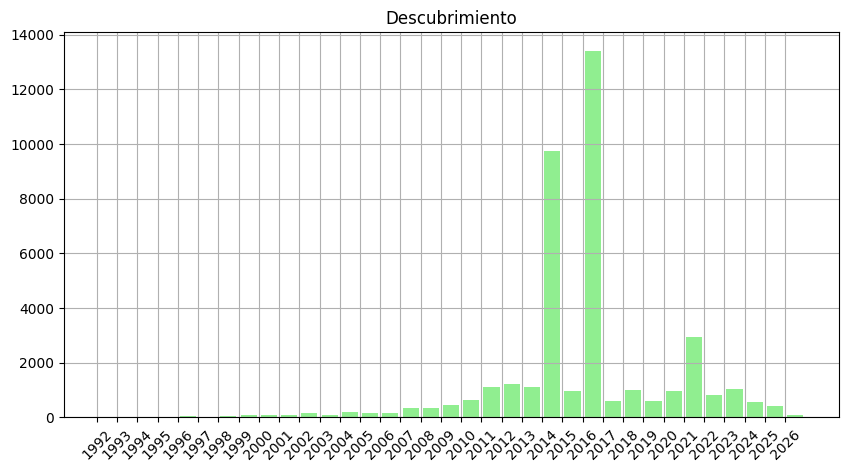

In [ ]:
# NUMERO DE DESCUBRIMIENTOS SEGUN EL AÑO

planets.hist("disc_year",
             color="lightgreen",
             rwidth=0.8,
             figsize=(10, 5),
             bins=range(int(planets["disc_year"].min()), int(planets["disc_year"].max())+2)
             )

#se ajusta la representación para que cada barra sea de un año
plt.xticks(range(int(planets["disc_year"].min()), int(planets["disc_year"].max())+1),
           rotation=45)

plt.title("Descubrimiento")

Text(0.5, 1.0, 'Masa (en masas terrestres)')

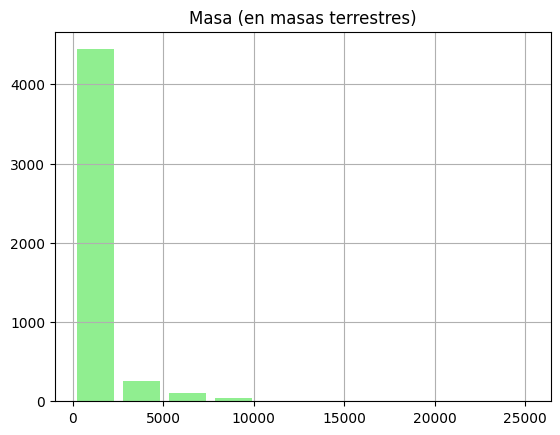

In [ ]:
# HISTOGRAMA DE MASAS

planets.hist("pl_masse",
             color="lightgreen",
             rwidth=0.8)
plt.title("Masa (en masas terrestres)")

    Los más habituales son los exoplanetas mayores que la Tierra en un rango de hasta 1000 veces, aunque hay ejemplos de más.

    El máximo encontrado es de 25426 veces la masa de la Tierra.

Text(0.5, 0, 'parsec')

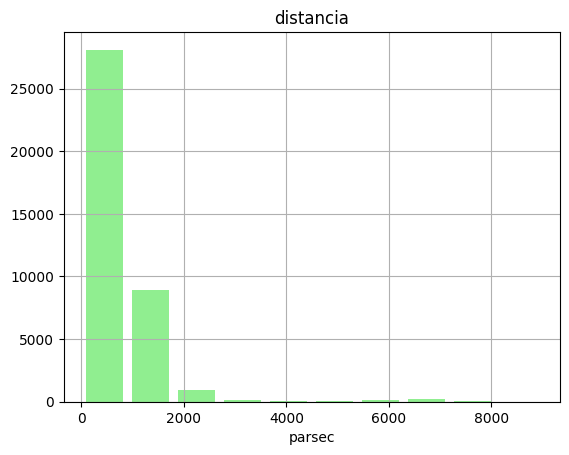

In [ ]:
# HISTOGRAMA DE DISTANCIAS

planets.hist("distancia",
             color="lightgreen",
             rwidth=0.8)
plt.xlabel("parsec")

    Cuanto más lejos, menos probable es detectarlos

In [ ]:
# MÉTODOS DE DESCUBRIMIENTO

planets["discoverymethod"].unique()

array(['Radial Velocity', 'Imaging', 'Eclipse Timing Variations',
       'Microlensing', 'Transit', 'Transit Timing Variations',
       'Astrometry', 'Disk Kinematics', 'Orbital Brightness Modulation',
       'Pulsation Timing Variations', 'Pulsar Timing'], dtype=object)

(0.0, 1600.0)

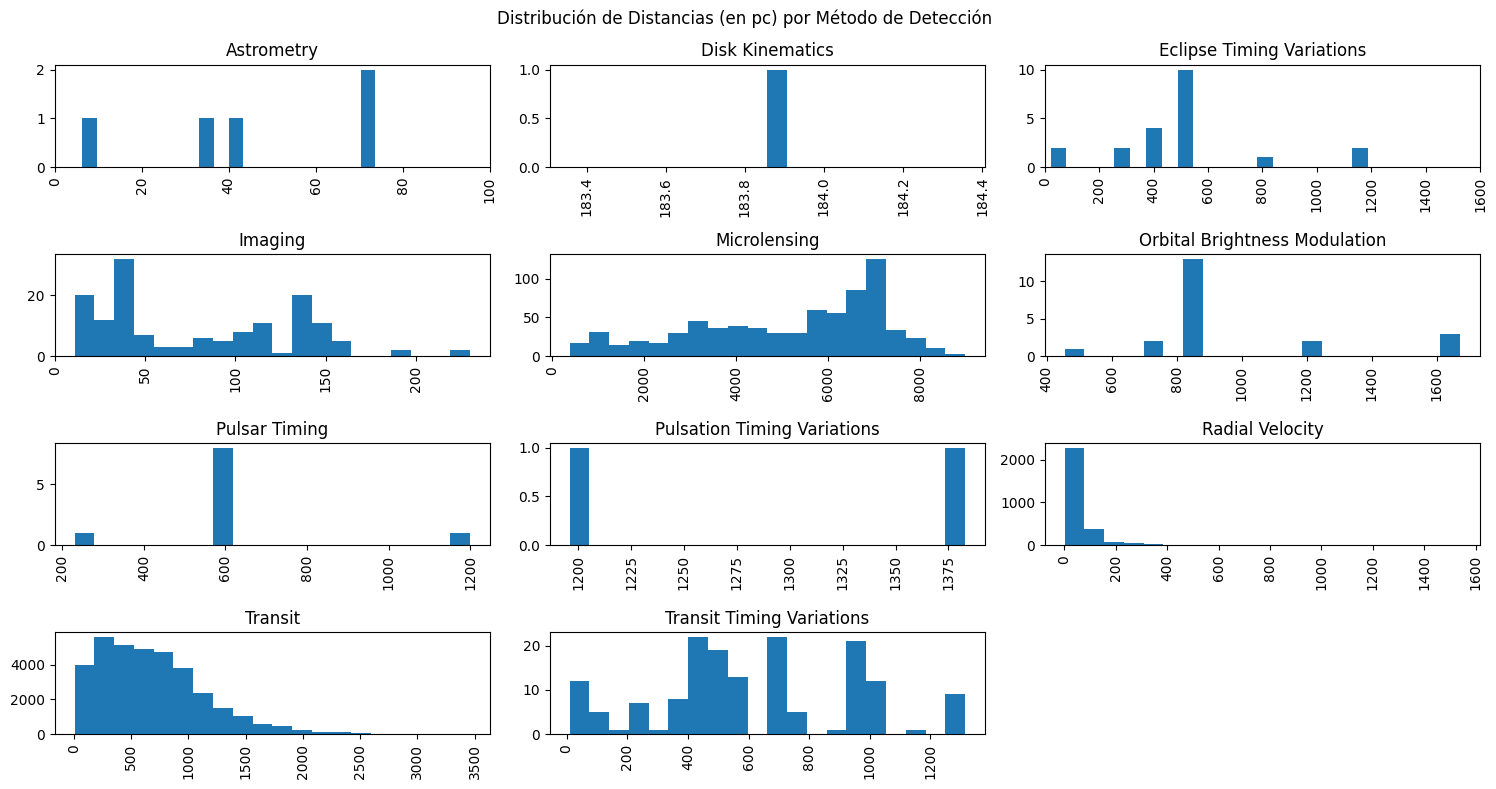

In [ ]:
# DISTANCIAS PARA CADA MÉTODO DE DESCUBRIMIENTO

axes = planets.hist(column='distancia', by='discoverymethod', figsize=(15, 8), bins=20)
plt.suptitle('Distribución de Distancias (en pc) por Método de Detección')
plt.tight_layout()

    Hay algunos casos en los que se pueden obtener conclusiones.
    Por ejemplo, el método del tránsito es más eficaz cuanto más cerca se encuentra ese sistema.
    En cambio, en otros casos como el método "disk kinematics" hay pocos casos.

    Hacemos lo mismo con la masa:

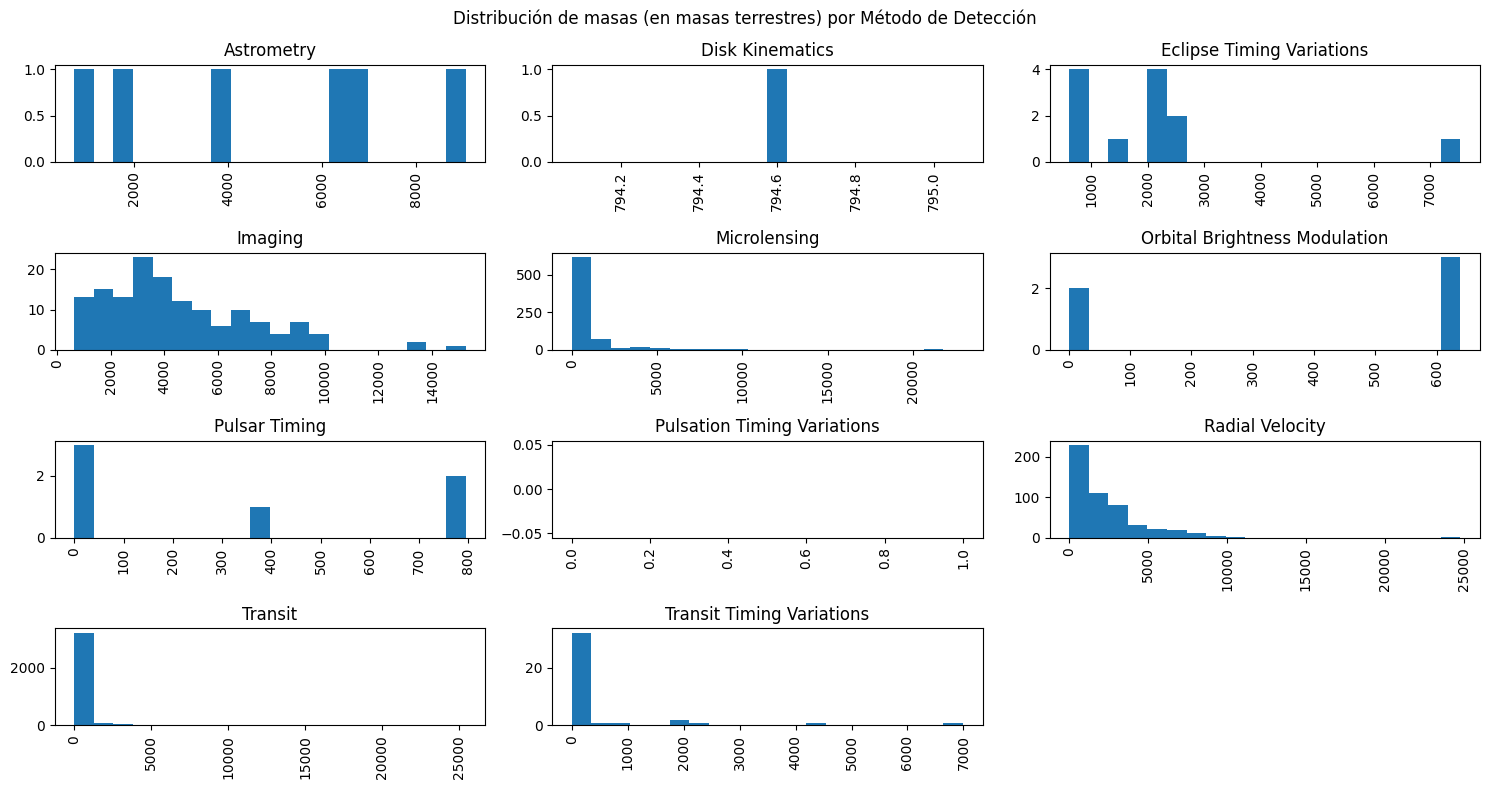

In [ ]:
# MASAS PARA CADA MÉTODO DE DESCUBRIMIENTO

axes = planets.hist(column='pl_masse', by='discoverymethod', figsize=(15, 8), bins=20)
plt.suptitle('Distribución de masas (en masas terrestres) por Método de Detección')
plt.tight_layout()

    De manera similar al caso anterior, vemos que se detectan más planetas con masas más
    similares a la tierra si se utilizan los métodos de velocidad radial y variaciones
    de tiempo de eclipse o tránsito entre otras.



---





---



### Análisis bivariable

<Axes: xlabel='disc_year', ylabel='distancia'>

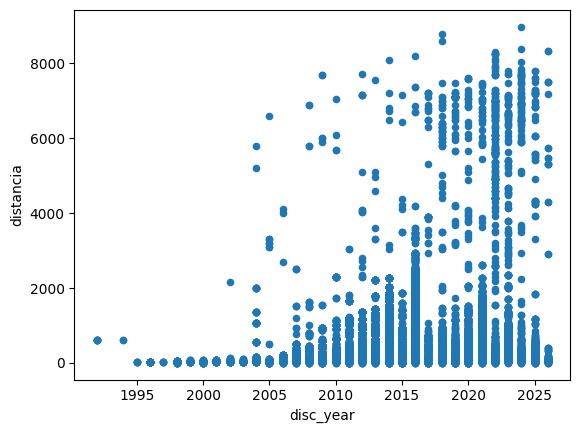

In [ ]:
planets.plot.scatter(x="disc_year", y="distancia")

<Axes: xlabel='distancia', ylabel='st_mass'>

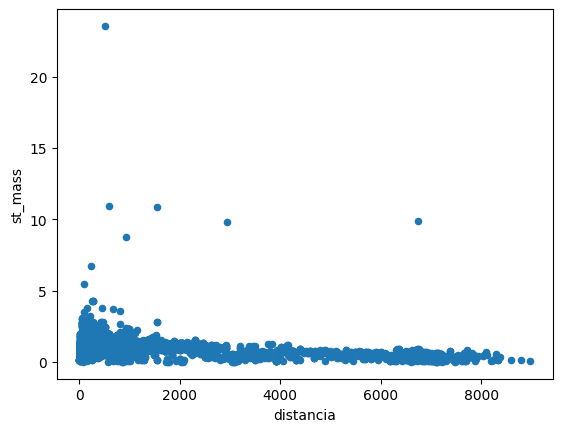

In [ ]:
planets.plot.scatter(x="distancia", y="st_mass")

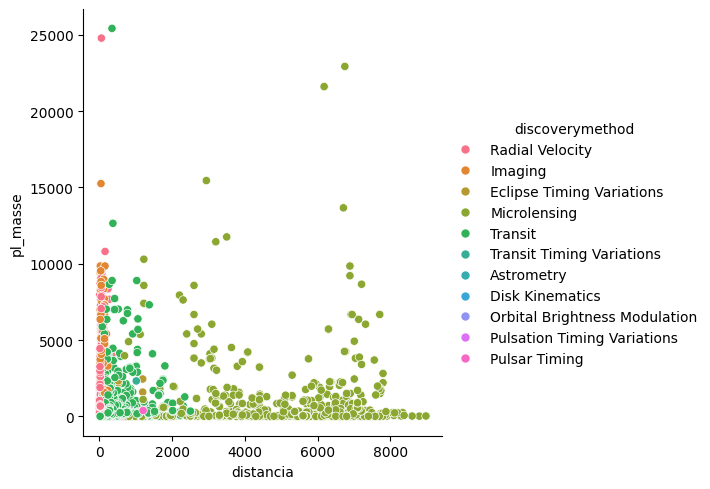

In [8]:
sns.relplot(x="distancia", y="pl_masse", hue="discoverymethod",  data=planets);